# Data Pipeline & Cleaning
### Delhivery Graph-Based Network Intelligence

**Goal:** Load the raw delivery data, fix every quality issue, engineer time features, and save clean files ready for graph construction

**Steps in this notebook:**
1. Load & inspect raw data
2. Parse datetime columns
3. Engineer time features
4. Fix missing hub names
5. Remove corrupt segment rows
6. Cap extreme factor outliers
7. Final dtype cleanup
8. Train / test split

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

C:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
OUT_DIR  = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)

### Load and inspect raw data

In [3]:
df = pd.read_csv("../data/delivery_data.csv" )
df.shape

(144867, 24)

In [4]:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [5]:
df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


In [6]:
df.isnull().sum()

data                                0
trip_creation_time                  0
route_schedule_uuid                 0
route_type                          0
trip_uuid                           0
source_center                       0
source_name                       293
destination_center                  0
destination_name                  261
od_start_time                       0
od_end_time                         0
start_scan_to_end_scan              0
is_cutoff                           0
cutoff_factor                       0
cutoff_timestamp                    0
actual_distance_to_destination      0
actual_time                         0
osrm_time                           0
osrm_distance                       0
factor                              0
segment_actual_time                 0
segment_osrm_time                   0
segment_osrm_distance               0
segment_factor                      0
dtype: int64

In [7]:
df.columns

Index(['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
       'trip_uuid', 'source_center', 'source_name', 'destination_center',
       'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor',
       'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time',
       'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance', 'segment_factor'],
      dtype='str')

### Parse datetime columns

In [8]:
datetime_cols = [
    "trip_creation_time",
    "od_start_time",
    "od_end_time",
    "cutoff_timestamp",
]

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")
    n_nat = df[col].isna().sum()
    print(f"  {col}   ({n_nat} NaT)")

print(f"  Earliest trip : {df['trip_creation_time'].min()}")
print(f"  Latest trip   : {df['trip_creation_time'].max()}")


  trip_creation_time   (0 NaT)
  od_start_time   (0 NaT)
  od_end_time   (0 NaT)
  cutoff_timestamp   (3429 NaT)
  Earliest trip : 2018-09-12 00:00:16.535741
  Latest trip   : 2018-10-03 23:59:42.701692


In [9]:
print(df['is_cutoff'].value_counts())
print(f"\ncutoff_timestamp NaT  : {df['cutoff_timestamp'].isna().sum()}")
print(f"is_cutoff False       : {(df['is_cutoff']==False).sum()}")
print(f"Difference            : {(df['is_cutoff']==False).sum() - df['cutoff_timestamp'].isna().sum()}")

is_cutoff
True     118749
False     26118
Name: count, dtype: int64

cutoff_timestamp NaT  : 3429
is_cutoff False       : 26118
Difference            : 22689


This will show that is_cutoff = False has 26,118 rows but only 3,429 have NaT timestamps. The remaining 22,689 rows have is_cutoff = False but still have a timestamp stored — meaning the system recorded a deadline but then flagged the trip as SLA-exempt.

### Engineer time features

- **Night (10 PM – 6 AM):** bulk inter-city FTL batches depart
- **Peak evening (6 PM – 10 PM):** last-mile Carting volume peaks
- **Weekend:** lighter commercial volume, different delay profile

In [10]:
df["hour_of_day"]    = df["trip_creation_time"].dt.hour
df["day_of_week"]    = df["trip_creation_time"].dt.dayofweek   # 0=Mon, 6=Sun

In [11]:
df["day_of_week"].value_counts()

day_of_week
2    26732
3    20481
4    20242
1    19961
5    19936
0    19645
6    17870
Name: count, dtype: int64

In [12]:
df["hour_of_day"].value_counts()

hour_of_day
22    12255
20    10329
19    10197
23     9343
1      8771
21     8735
0      8299
18     7783
2      7321
4      6639
5      6183
17     5976
3      4976
6      4407
13     4294
15     4274
14     4273
16     3862
8      3596
10     2880
7      2708
11     2691
9      2612
12     2463
Name: count, dtype: int64

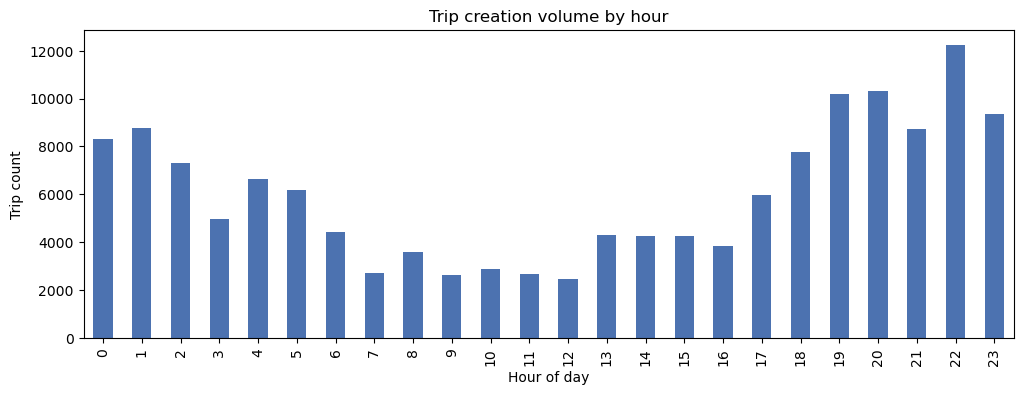

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
df["hour_of_day"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Trip count")
ax.set_title("Trip creation volume by hour")
plt.show()

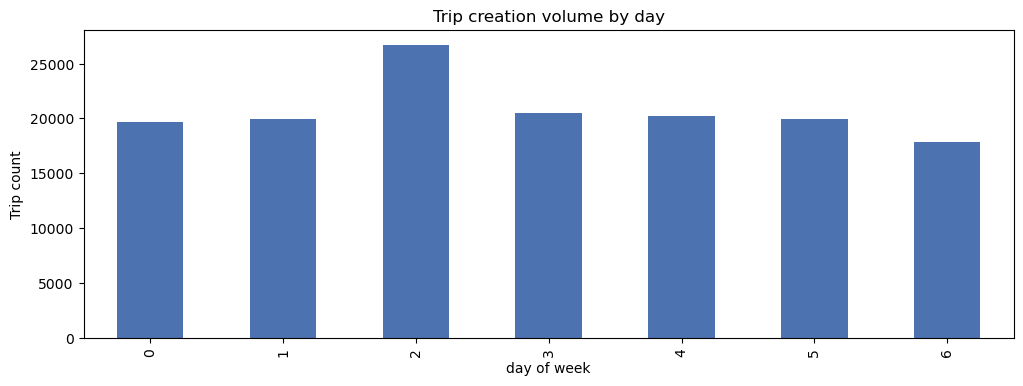

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
df["day_of_week"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("day of week")
ax.set_ylabel("Trip count")
ax.set_title("Trip creation volume by day")
plt.show()

In [15]:
# Time phase creation
df["is_weekend"]     = df["day_of_week"].isin([5, 6]).astype(int)
df["is_night"]       = (df["hour_of_day"].between(0, 5) | df["hour_of_day"].ge(22)).astype(int)
df["is_peak_evening"]= df["hour_of_day"].between(18, 21).astype(int)

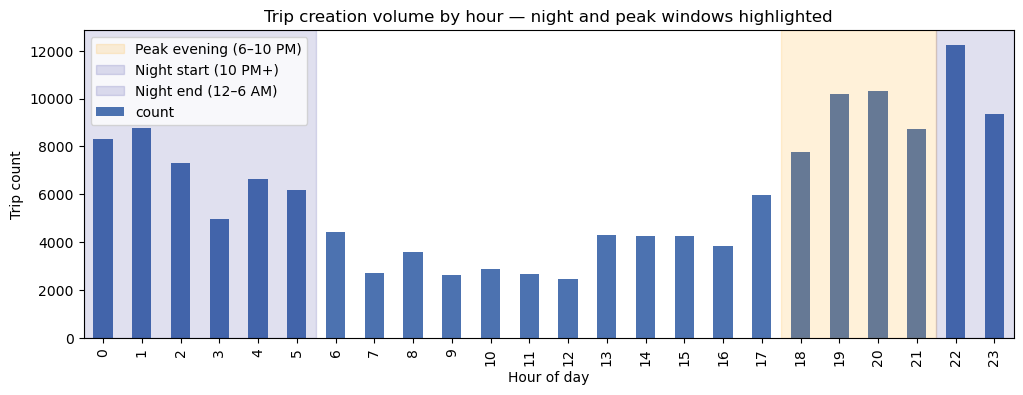

In [16]:
# Visualise trip creation hour distribution
fig, ax = plt.subplots(figsize=(12, 4))
df["hour_of_day"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.axvspan(17.5, 21.5, alpha=0.15, color="orange", label="Peak evening (6–10 PM)")
ax.axvspan(21.5, 23.5, alpha=0.12, color="navy",   label="Night start (10 PM+)")
ax.axvspan(-0.5, 5.5,  alpha=0.12, color="navy",   label="Night end (12–6 AM)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Trip count")
ax.set_title("Trip creation volume by hour — night and peak windows highlighted")
ax.legend()
plt.show()


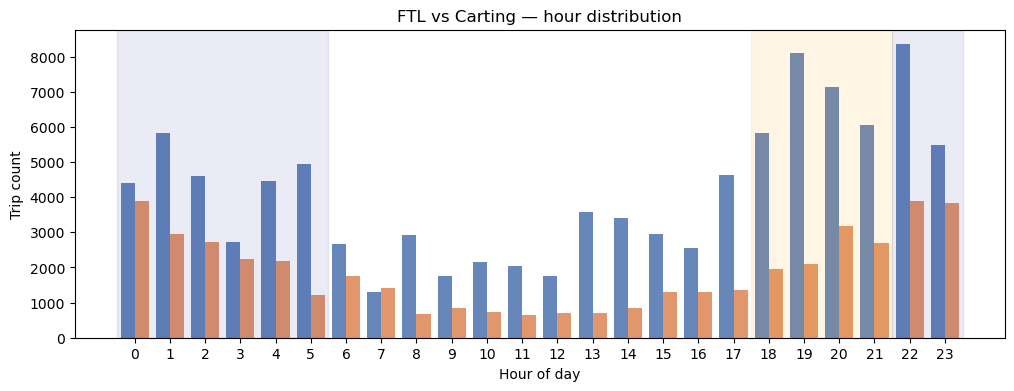

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))

#  FTL vs Carting by hour 
ftl_hours     = df[df["route_type"]=="FTL"]["hour_of_day"].value_counts().sort_index()
carting_hours = df[df["route_type"]=="Carting"]["hour_of_day"].value_counts().sort_index()

x     = range(24)
width = 0.4
ax.bar([i - width/2 for i in x], ftl_hours.reindex(range(24), fill_value=0),
            width=width, color="#4C72B0", label="FTL", alpha=0.85)
ax.bar([i + width/2 for i in x], carting_hours.reindex(range(24), fill_value=0),
            width=width, color="#DD8452", label="Carting", alpha=0.85)
ax.axvspan(17.5, 21.5, alpha=0.1, color="orange")
ax.axvspan(21.5, 23.5, alpha=0.08, color="navy")
ax.axvspan(-0.5, 5.5,  alpha=0.08, color="navy")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Trip count")
ax.set_title("FTL vs Carting — hour distribution")
ax.set_xticks(range(24))

plt.show()

In [18]:
print("Route type by time window:")
for window, mask in [
    ("Night",        (df["is_night"]==1)),
    ("Peak evening", (df["is_peak_evening"]==1)),
    ("Day",          ((df["is_night"]==0)&(df["is_peak_evening"]==0)))
]:
    sub = df[mask]
    ftl_pct = (sub["route_type"]=="FTL").mean()*100
    print(f"  {window:<15} — FTL: {ftl_pct:.1f}%  Carting: {100-ftl_pct:.1f}%")

Route type by time window:
  Night           — FTL: 64.0%  Carting: 36.0%
  Peak evening    — FTL: 73.2%  Carting: 26.8%
  Day             — FTL: 72.0%  Carting: 28.0%


### Fix missing hub names

293 rows have no `source_name` and 261 have no `destination_name`.
The center **codes** (`source_center`, `destination_center`) are always present.

**Strategy:**
1. Build a `center_code → name` lookup from rows that do have names
2. Fill the gaps using this lookup
3. For codes with no name anywhere in the dataset, use the code itself as a fallback

In [19]:
# Build lookup: most frequent name per center code
src_lookup = (df.dropna(subset=["source_name"])
               .groupby("source_center")["source_name"]
               .agg(lambda x: x.mode()[0]))

dst_lookup = (df.dropna(subset=["destination_name"])
               .groupby("destination_center")["destination_name"]
               .agg(lambda x: x.mode()[0]))

# Fill from lookup
df["source_name"]      = df["source_name"].fillna(df["source_center"].map(src_lookup))
df["destination_name"] = df["destination_name"].fillna(df["destination_center"].map(dst_lookup))

# use center code for any remaining
df["source_name"]      = df["source_name"].fillna(df["source_center"])
df["destination_name"] = df["destination_name"].fillna(df["destination_center"])

print(f"  source_name missing (after filling) : {df['source_name'].isna().sum()}")
print(f"  destination_name missing (after filling) : {df['destination_name'].isna().sum()}")


  source_name missing (after filling) : 0
  destination_name missing (after filling) : 0


###  Remove corrupt segment rows

#### Why we remove these rows

Two types of corrupt rows exist in the data, discovered through
domain constraint validation — checking for values that are
physically impossible in a logistics context.

**Type 1 — `segment_osrm_time = 0` (2,347 rows)**

When OSRM cannot compute a route for a hop (e.g. very short
same-building moves, hops below OSRM's spatial resolution),
it returns 0. Delhivery's system stores a sentinel value of
`segment_factor = -1.0` for these rows.

These rows are unusable as graph edge weights because:
- `segment_factor = actual / osrm_time = actual / 0` is undefined
- The -1.0 sentinel is not a real delay ratio
- Including them would corrupt corridor edge weights

All 2,347 rows have exactly `segment_factor = -1.0` — confirming
this is a systematic data flag, not random noise.

**Type 2 — `segment_actual_time < 0` (21 rows)**

A negative actual time means the arrival scan was recorded
before the departure scan. This is physically impossible —
it indicates a data entry or system clock error.

These rows produce negative computed segment_factors
(ranging from -0.02 to -23.4) because:
`segment_factor = negative_actual / positive_osrm = negative`

Note: 3 rows satisfy both conditions (zero OSRM time AND
negative actual time). The union `corrupt | neg_actual`
handles this overlap correctly without double-counting.

In [20]:
df[df["segment_factor"] < 0]["segment_osrm_time"].value_counts()

segment_osrm_time
0.0     2347
30.0       3
14.0       2
11.0       2
22.0       1
9.0        1
33.0       1
19.0       1
46.0       1
63.0       1
21.0       1
15.0       1
4.0        1
27.0       1
25.0       1
Name: count, dtype: int64

In [21]:
corrupt = df["segment_osrm_time"] == 0
print(f"segment_osrm_time = 0     : {corrupt.sum()} rows")

print("segment_factor values for corrupt rows:")
print(df[corrupt]["segment_factor"].value_counts())


segment_osrm_time = 0     : 2347 rows
segment_factor values for corrupt rows:
segment_factor
-1.0    2347
Name: count, dtype: int64


In [22]:
neg_actual = df["segment_actual_time"] < 0
print(f"segment_actual_time < 0   : {neg_actual.sum()} rows")

print(df[neg_actual]["segment_factor"].value_counts())

segment_actual_time < 0   : 21 rows
segment_factor
-1.000000     3
-1.857143     1
-0.700000     1
-0.454545     1
-2.636364     1
-23.444444    1
-0.363636     1
-1.894737     1
-0.021739     1
-0.666667     1
-2.428571     1
-8.133333     1
-0.100000     1
-4.933333     1
-1.250000     1
-3.428571     1
-0.592593     1
-0.636364     1
-0.600000     1
Name: count, dtype: int64


In [23]:
# Combined — everything we need to drop
drop = corrupt | neg_actual
print(f"\nTotal corrupt rows to drop : {drop.sum()}")
print(f"As % of dataset            : {drop.mean()*100:.2f}%")


Total corrupt rows to drop : 2365
As % of dataset            : 1.63%


In [24]:
print(f"segment_osrm_time = 0   : {corrupt.sum():,} rows")
print(f"segment_actual_time < 0 : {neg_actual.sum():,} rows")
print(f"Total to drop           : {drop.sum():,} rows  ({drop.mean()*100:.2f}%)")

df = df[~drop].copy()

print(f"\nRows remaining: {len(df):,}")


segment_osrm_time = 0   : 2,347 rows
segment_actual_time < 0 : 21 rows
Total to drop           : 2,365 rows  (1.63%)

Rows remaining: 142,502



### Cap extreme factor outliers

**Problem:** `factor` goes up to 77× and `segment_factor` to extreme values.

These are almost certainly **data artifacts** — shipments that sat in a
warehouse for days with no scans, not real transit delays. Including them
would skew the graph edge weights and model training badly.

**Strategy:** cap at the 99th percentile (data-driven, not arbitrary).
We cap rather than drop — the row still contributes, just with a
bounded weight.


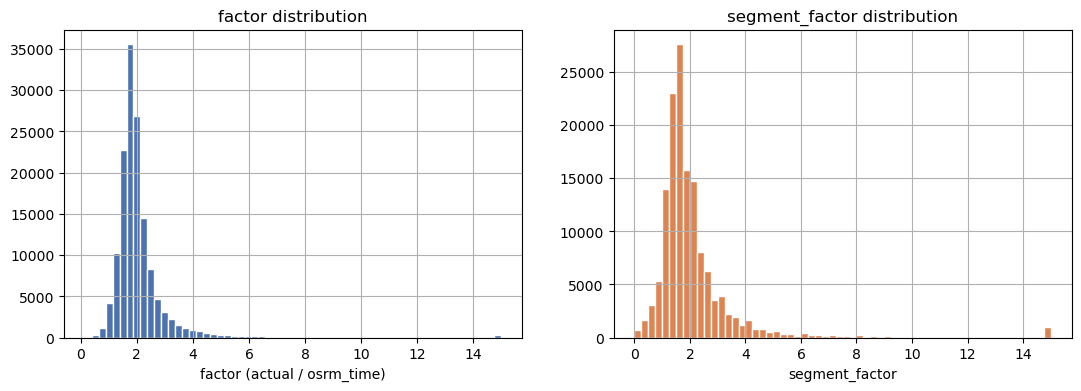

factor         : mean=2.11  median=1.86  max=77.39
segment_factor : mean=2.27  median=1.70  max=574.25


In [25]:
# Visualise factor distribution BEFORE capping
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["factor"].clip(upper=15).hist(bins=60, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("factor distribution")
axes[0].set_xlabel("factor (actual / osrm_time)")

df["segment_factor"].clip(upper=15).hist(bins=60, ax=axes[1], color="#DD8452", edgecolor="white")
axes[1].set_title("segment_factor distribution")
axes[1].set_xlabel("segment_factor")

plt.show()

print(f"factor         : mean={df['factor'].mean():.2f}  median={df['factor'].median():.2f}  max={df['factor'].max():.2f}")
print(f"segment_factor : mean={df['segment_factor'].mean():.2f}  median={df['segment_factor'].median():.2f}  max={df['segment_factor'].max():.2f}")


In [26]:
FACTOR_CAP = df["factor"].quantile(0.99)
SEG_CAP    = df["segment_factor"].quantile(0.99)

print(f"Capping factor         at 99th percentile: {FACTOR_CAP:.2f}")
print(f"Capping segment_factor at 99th percentile: {SEG_CAP:.2f}")


df["factor"] = df["factor"].clip(upper=FACTOR_CAP)
df["segment_factor"] = df["segment_factor"].clip(upper=SEG_CAP)


Capping factor         at 99th percentile: 6.90
Capping segment_factor at 99th percentile: 11.60


In [27]:
# After clipping — count how many are exactly at the cap value
print(f"Rows at factor cap    : {(df['factor']==FACTOR_CAP).sum():,}")
print(f"Rows at seg_factor cap: {(df['segment_factor']==SEG_CAP).sum():,}")

Rows at factor cap    : 1,426
Rows at seg_factor cap: 1,427


### Final dtype cleanup

In [28]:
df["route_type"] = df["route_type"].astype("category")
df["data"]       = df["data"].astype("category")
df["is_cutoff"]  = df["is_cutoff"].astype(bool)

print(df.dtypes)

data                                    category
trip_creation_time                datetime64[us]
route_schedule_uuid                          str
route_type                              category
trip_uuid                                    str
source_center                                str
source_name                                  str
destination_center                           str
destination_name                             str
od_start_time                     datetime64[us]
od_end_time                       datetime64[us]
start_scan_to_end_scan                   float64
is_cutoff                                   bool
cutoff_factor                              int64
cutoff_timestamp                  datetime64[us]
actual_distance_to_destination           float64
actual_time                              float64
osrm_time                                float64
osrm_distance                            float64
factor                                   float64
segment_actual_time 

### Train / test split

In [29]:
df_train = df[df["data"] == "training"].copy()
df_test  = df[df["data"] == "test"].copy()

print(f"Train : {len(df_train):,} rows  ({len(df_train)/len(df)*100:.1f}%)")
print(f"Test  : {len(df_test):,} rows  ({len(df_test)/len(df)*100:.1f}%)")

df.to_parquet(f"{OUT_DIR}/clean_all.parquet", index=False)
df_train.to_parquet(f"{OUT_DIR}/clean_train.parquet", index=False)
df_test.to_parquet(f"{OUT_DIR}/clean_test.parquet", index=False)

Train : 103,126 rows  (72.4%)
Test  : 39,376 rows  (27.6%)


In [30]:
df.to_csv(f"{OUT_DIR}/clean_all.csv",   index=False)

In [31]:
# Load the saved file back
df_check = pd.read_parquet("../outputs/clean_all.parquet")

print(f"Shape          : {df_check.shape}")
print(f"Nulls          : {df_check.isnull().sum()[df_check.isnull().sum() > 0]}")
print(f"factor max     : {df_check['factor'].max():.2f}")
print(f"seg_factor min : {df_check['segment_factor'].min():.2f}")
print(f"route_type     : {df_check['route_type'].value_counts().to_dict()}")

Shape          : (142502, 29)
Nulls          : cutoff_timestamp    3005
dtype: int64
factor max     : 6.90
seg_factor min : 0.00
route_type     : {'FTL': 98827, 'Carting': 43675}
